Python application which performs sentiment analysis on a dataset of product reviews.



In [1]:
!pip install spacy
!python -m spacy download en_core_web_md
!pip install spacytextblob
!python -m textblob.download_corpora

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 44.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading 

In [1]:
#load modules
import pandas as pd
import numpy as np
from spacytextblob.spacytextblob import SpacyTextBlob

In [20]:
#load data file
try:
  df = pd.read_csv(
      "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv",
      engine="python",
      #on_bad_lines="skip"
  )
except Exception as e:
  print(e)

In [21]:
#Pre-processing
print(df.isnull().sum())

id                         0
dateAdded                  0
dateUpdated                0
name                       0
asins                      0
brand                      0
categories                 0
primaryCategories          0
imageURLs                  0
keys                       0
manufacturer               0
manufacturerNumber         0
reviews.date               0
reviews.dateSeen           0
reviews.didPurchase    28323
reviews.doRecommend    12246
reviews.id             28291
reviews.numHelpful     12217
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title              0
reviews.username           5
sourceURLs                 0
dtype: int64


Delete the columns that have many missing data.

In [23]:
#We only actually need the reviews.text for this Task
df = df[['name', 'reviews.text']]

In [24]:
import spacy
nlp_md = spacy.load("en_core_web_md")
nlp_md.add_pipe('spacytextblob')

In [25]:
reviews_data = df['reviews.text']
clean_data = df.dropna(subset=['reviews.text'])
# dropna() not needed in this case since there is no missing data

In [26]:

def sentiment_analysis(data):
  data = str(data)
  data = data.lower()
  data = data.strip()
  doc = nlp_md(data)
  polarity = doc._.blob.polarity
  sentiment = doc._.blob.sentiment
  if polarity > 0.15:
    sentiment_label = "Positive"
  elif polarity < -0.15:
    sentiment_label = "Negative"
  else:
    sentiment_label = "Neutral"
  return data, sentiment, sentiment_label

In [27]:
sentence= reviews_data[555]
sentence

'Batteries were packaged good and seem fine'

In [28]:
sentiment_analysis(sentence)

('batteries were packaged good and seem fine',
 Sentiment(polarity=0.5583333333333333, subjectivity=0.55),
 'Positive')

In [29]:
len(df["reviews.text"])

28332

In [30]:
#testing the function for the first 147 review
negative_count=0
positive_count=0
neutral_count=0
for i in range(len(df["reviews.text"])):
  data, sentiment, sentiment_label = sentiment_analysis(reviews_data[i])
  #print(data, sentiment_label, sentiment)
  if sentiment_label == "Negative":
    negative_count+=1
  elif sentiment_label == "Positive":
    positive_count+=1
  else:
    neutral_count+=1

print(negative_count, positive_count, neutral_count)

732 21027 6573


In [31]:
#To make the process easier it would be better to create a function that adds
#the results as columns in the dataset

def get_sentiment_data(review):
    clean_text = str(review).lower().strip()
    doc = nlp_md(clean_text)
    polarity = doc._.blob.polarity
    sentiment_obj = doc._.blob.sentiment

    # Using your preferred 0.15 threshold
    if polarity > 0.15:
        label = "Positive"
    elif polarity < -0.15:
        label = "Negative"
    else:
        label = "Neutral"

    return pd.Series([sentiment_obj[0], sentiment_obj[1], label])

#create the columns
df[['polarity', 'sentiment', 'sentiment_label']] = df[
    'reviews.text'].apply(get_sentiment_data)

# check counts
print(df['sentiment_label'].value_counts())

sentiment_label
Positive    21027
Neutral      6573
Negative      732
Name: count, dtype: int64


In [32]:
df.head(20)

,name,reviews.text,polarity,sentiment,sentiment_label
0,AmazonBasics AAA Performance Alkaline Batterie...,I order 3 of them and one of the item is bad q...,-0.450000,0.358333,Negative
1,AmazonBasics AAA Performance Alkaline Batterie...,Bulk is always the less expensive way to go fo...,-0.333333,0.383333,Negative
2,AmazonBasics AAA Performance Alkaline Batterie...,Well they are not Duracell but for the price i...,0.800000,1.000000,Positive
3,AmazonBasics AAA Performance Alkaline Batterie...,Seem to work as well as name brand batteries a...,0.500000,0.500000,Positive
4,AmazonBasics AAA Performance Alkaline Batterie...,These batteries are very long lasting the pric...,0.245000,0.423333,Positive
5,AmazonBasics AAA Performance Alkaline Batterie...,Bought a lot of batteries for Christmas and th...,0.350000,0.362500,Positive
6,AmazonBasics AAA Performance Alkaline Batterie...,ive not had any problame with these batteries ...,0.200000,0.625000,Positive
7,AmazonBasics AAA Performance Alkaline Batterie...,Well if you are looking for cheap non-recharge...,0.475000,0.566667,Positive
8,AmazonBasics AAA Performance Alkaline Batterie...,These do not hold the amount of high power jui...,-0.003333,0.353333,Neutral
9,AmazonBasics AAA Performance Alkaline Batterie...,AmazonBasics AA AAA batteries have done well b...,0.700000,0.600000,Positive


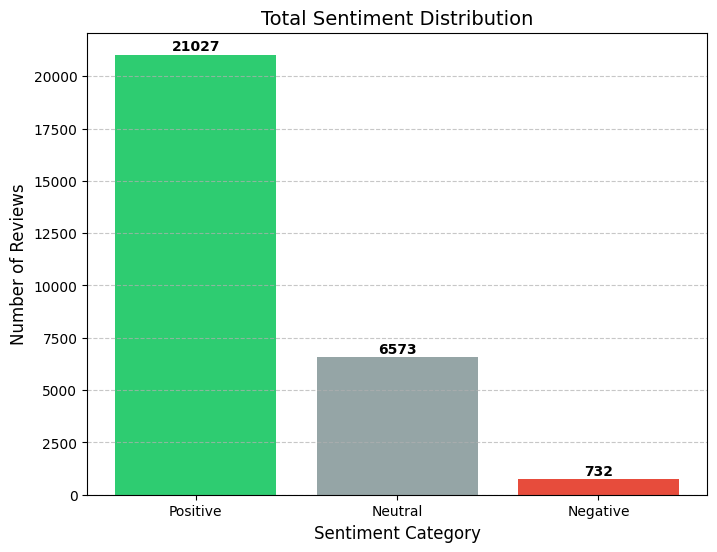

In [33]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(8, 6))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ecc71', '#95a5a6', '#e74c3c'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Total Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('sentiment_totals.png')
plt.show()

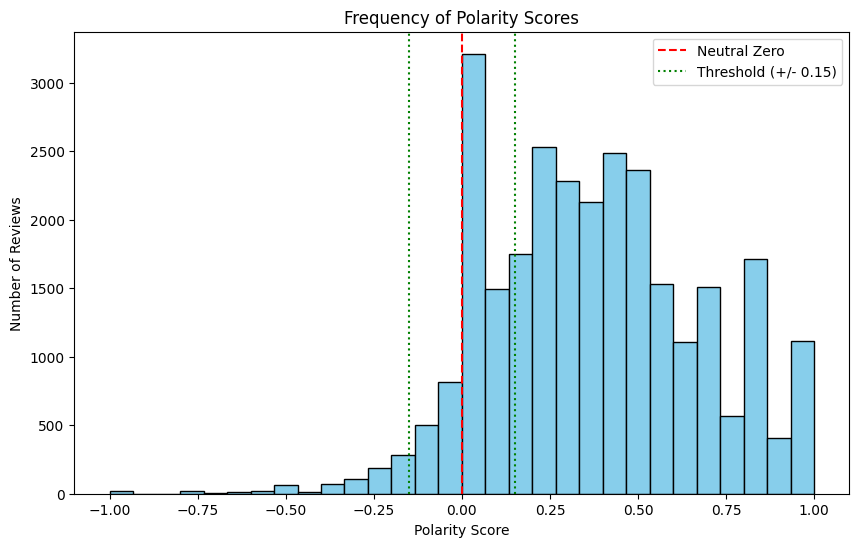

In [34]:
# Plotting the Polarity Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['polarity'], bins=30, color='skyblue', edgecolor='black')

# Adding a line for the Neutral Zero and your thresholds
plt.axvline(0, color='red', linestyle='dashed', label='Neutral Zero')
plt.axvline(0.15, color='green', linestyle='dotted', label='Threshold (+/- 0.15)')
plt.axvline(-0.15, color='green', linestyle='dotted')

plt.title('Frequency of Polarity Scores')
plt.xlabel('Polarity Score')
plt.ylabel('Number of Reviews')
plt.legend()
plt.savefig('polarity_histogram.png')

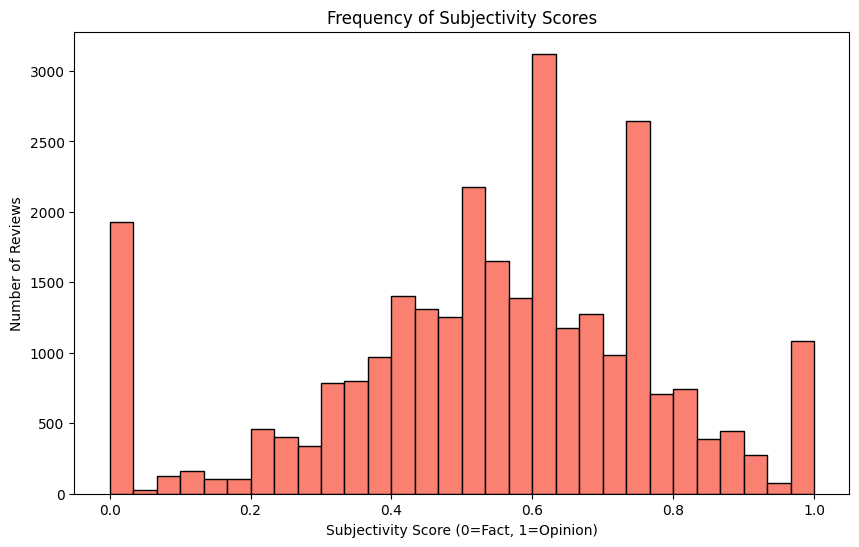

In [35]:
# Plotting the Subjectivity Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['sentiment'], bins=30, color='salmon', edgecolor='black')

plt.title('Frequency of Subjectivity Scores')
plt.xlabel('Subjectivity Score (0=Fact, 1=Opinion)')
plt.ylabel('Number of Reviews')
plt.savefig('subjectivity_histogram.png')

In [36]:
df.head()

,name,reviews.text,polarity,sentiment,sentiment_label
0,AmazonBasics AAA Performance Alkaline Batterie...,I order 3 of them and one of the item is bad q...,-0.450000,0.358333,Negative
1,AmazonBasics AAA Performance Alkaline Batterie...,Bulk is always the less expensive way to go fo...,-0.333333,0.383333,Negative
2,AmazonBasics AAA Performance Alkaline Batterie...,Well they are not Duracell but for the price i...,0.800000,1.000000,Positive
3,AmazonBasics AAA Performance Alkaline Batterie...,Seem to work as well as name brand batteries a...,0.500000,0.500000,Positive
4,AmazonBasics AAA Performance Alkaline Batterie...,These batteries are very long lasting the pric...,0.245000,0.423333,Positive


In [37]:
# get 30 random values from the Positive, Neutral and Negative sentiment_label groups.
labels = ['Negative', 'Positive', 'Neutral']
sample_size = 30
df_samples = df[['sentiment_label', 'reviews.text', 'polarity']]
samples = []
for label in labels:
    subset = df_samples[df_samples['sentiment_label'] == label]

    sampled_subset = subset.sample(n=sample_size, random_state=42)

    # Add to our list
    samples.append(sampled_subset)

final_sample_df = pd.concat(samples)
final_sample_df.to_csv('sampled_reviews.csv', index=False)

In [38]:
print(samples)

[      sentiment_label                                       reviews.text  \
21594        Negative  This is not like other android tablets in a ba...   
927          Negative  Disappointed by the amount of time these batte...   
8461         Negative  WORST batteries EVER. I thought there would be...   
13174        Negative  It is a very solid E-Reader. Nothing wrong wit...   
22879        Negative  I bought this for my grandson and it hasn't di...   
18905        Negative  I bought this as a Christmas gift for my wife ...   
964          Negative  DOA. Had to replace with other batteries. What...   
11292        Negative  These batteries leaked into my mouse and kille...   
27992        Negative  The fire runs well and was easy to set up. The...   
16975        Negative  Not easy for elderly users cease of ads that p...   
12047        Negative  These batteries are the worst batteries I've e...   
11288        Negative  I bought 20 and I used 9 in three Motorola Wal...   
6642       